# E-Commerce Customer Churn Prediction
**Goal:** Predict whether a customer will churn based on demographics, activity, purchase behaviour, and engagement patterns.

**Workflow:**
1. Imports
2. Data Loading & Initial Inspection
3. Data Cleaning
4. Outlier Handling
5. Exploratory Data Analysis (EDA)
6. Encoding & Train/Test Split
7. Scaling
8. Model Comparison — Default Parameters
9. Model Comparison — SMOTE Oversampling (Default Params)
10. Model Comparison — Random Undersampling (Default Params)
11. Default Summary Table — All 3 Strategies
12. Hyperparameter Tuning — Top Models on Original Data
13. Hyperparameter Tuning — Top Models on SMOTE Data
14. Hyperparameter Tuning — Top Models on Undersampled Data
15. Grand Summary Table — All 6 Strategies
16. Final Model Evaluation & Threshold Tuning
17. Overfitting / Underfitting Check
18. Feature Importances
19. Save Artifacts

## 1. Imports

In [1]:
# --- Import all the libraries we need ---

# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warning messages so the output stays clean
import warnings
warnings.filterwarnings('ignore')

# Tools for splitting data, tuning models, and scaling features
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler

# All the classification models we will compare
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Metrics to evaluate how good each model is
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# Tools to handle class imbalance (more non-churned than churned customers)
from imblearn.over_sampling import SMOTE             # creates synthetic minority samples
from imblearn.under_sampling import RandomUnderSampler  # removes excess majority samples

# Set a consistent visual style for all plots
sns.set_theme(style='whitegrid', palette='muted')

## 2. Data Loading & Initial Inspection

In [2]:
# Load the dataset from a CSV file into a DataFrame
df = pd.read_csv('ecommerce_customer_churn_dataset.csv')

In [3]:
# Preview the first 5 rows to see what the data looks like
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [4]:
# Check how many rows and columns we have (rows, columns)
df.shape

(50000, 25)

In [5]:
# See the column names, data types, and how many non-null values exist
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [6]:
# Get basic statistics for each numeric column (mean, min, max, etc.)
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,...,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,...,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,...,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,...,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,...,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


## 3. Data Cleaning

| Column | Reason for Dropping |
|---|---|
| `Country` | High cardinality — too many unique values, noisy |
| `City` | Same as Country — too granular |
| `Signup_Quarter` | Very weak signal for churn prediction |

In [7]:
# Drop columns that are not useful for predicting churn
# 'Country' and 'City' have too many unique values (high cardinality)
# 'Signup_Quarter' has very little predictive power
df = df.drop(columns=['Country', 'City', 'Signup_Quarter'])

print("Shape after dropping columns:", df.shape)

Shape after dropping columns: (50000, 22)


In [8]:
# Check how many missing (null) values are in each column
print("Null counts:")
print(df.isnull().sum())

Null counts:
Age                              2495
Gender                              0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
dtype: int64


In [9]:
# Fill missing values in numeric columns with the median of that column
# The median is used because it's less affected by extreme values than the mean
df.fillna(df.median(numeric_only=True), inplace=True)

# Confirm all nulls are gone
print("Nulls after filling:", df.isnull().sum().sum())

# Check for any duplicate rows
print("Duplicates:", df.duplicated().sum())

Nulls after filling: 0
Duplicates: 0


In [10]:
# Fix data types — these columns should be whole numbers (integers), not decimals
int_columns = [
    'Age',
    'Wishlist_Items',
    'Total_Purchases',
    'Days_Since_Last_Purchase',
    'Customer_Service_Calls',
    'Product_Reviews_Written',
    'Payment_Method_Diversity'
]

# Convert each of those columns to integer type
df[int_columns] = df[int_columns].astype(int)

# 'Gender' contains text labels, so we convert it to a categorical type
df['Gender'] = df['Gender'].astype('category')

print("Data types fixed.")

Data types fixed.


## 4. Outlier Handling
- **Age**: Filtered to 15–90 (removed values like 5, 150, 200)
- **Cart_Abandonment_Rate**: Clipped at 100 (percentage — cannot exceed 100)

Outliers properly managed → **StandardScaler** is appropriate.

In [11]:
# Inspect extreme values in the Age column to see if there are any unrealistic entries
all_ages_sorted = sorted(df['Age'].unique())
print("Age extremes:", all_ages_sorted[:5], '...', all_ages_sorted[-5:])

# Check the maximum value in Cart_Abandonment_Rate (should not exceed 100%)
print("Cart_Abandonment_Rate max:", df['Cart_Abandonment_Rate'].max())

Age extremes: [np.int64(5), np.int64(10), np.int64(18), np.int64(19), np.int64(20)] ... [np.int64(73), np.int64(74), np.int64(75), np.int64(150), np.int64(200)]
Cart_Abandonment_Rate max: 143.74335014288403


In [12]:
# Remove rows where Age is unrealistic (below 15 or above 90)
df = df[(df['Age'] >= 15) & (df['Age'] <= 90)]

# Cap Cart_Abandonment_Rate at 100 — a percentage cannot be greater than 100
df['Cart_Abandonment_Rate'] = df['Cart_Abandonment_Rate'].clip(upper=100)

print("Shape after outlier handling:", df.shape)

Shape after outlier handling: (49950, 22)


## 5. Exploratory Data Analysis (EDA)

### 5.1 Target Variable — Churn Distribution

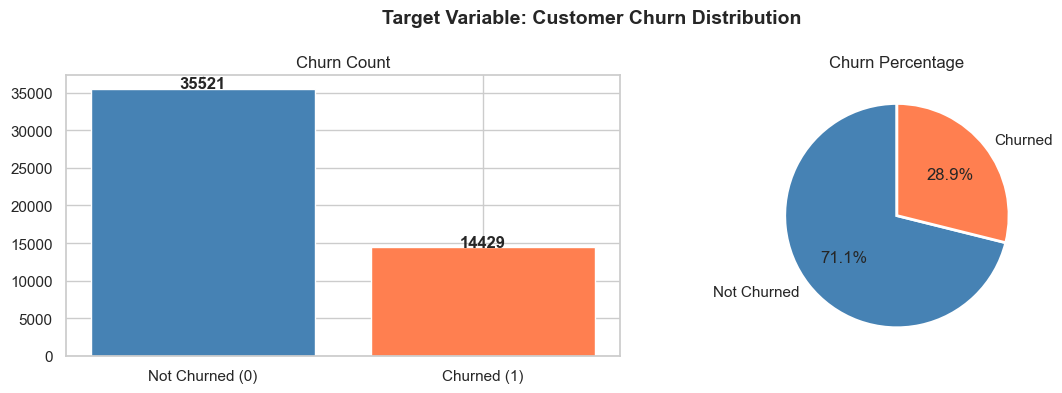

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
churn_counts = df['Churned'].value_counts()
axes[0].bar(['Not Churned (0)', 'Churned (1)'], churn_counts.values,
            color=['steelblue', 'coral'], edgecolor='white')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')
axes[0].set_title('Churn Count')
axes[1].pie(churn_counts.values, labels=['Not Churned', 'Churned'],
            autopct='%1.1f%%', colors=['steelblue', 'coral'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Percentage')
plt.suptitle('Target Variable: Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Demographics vs Churn

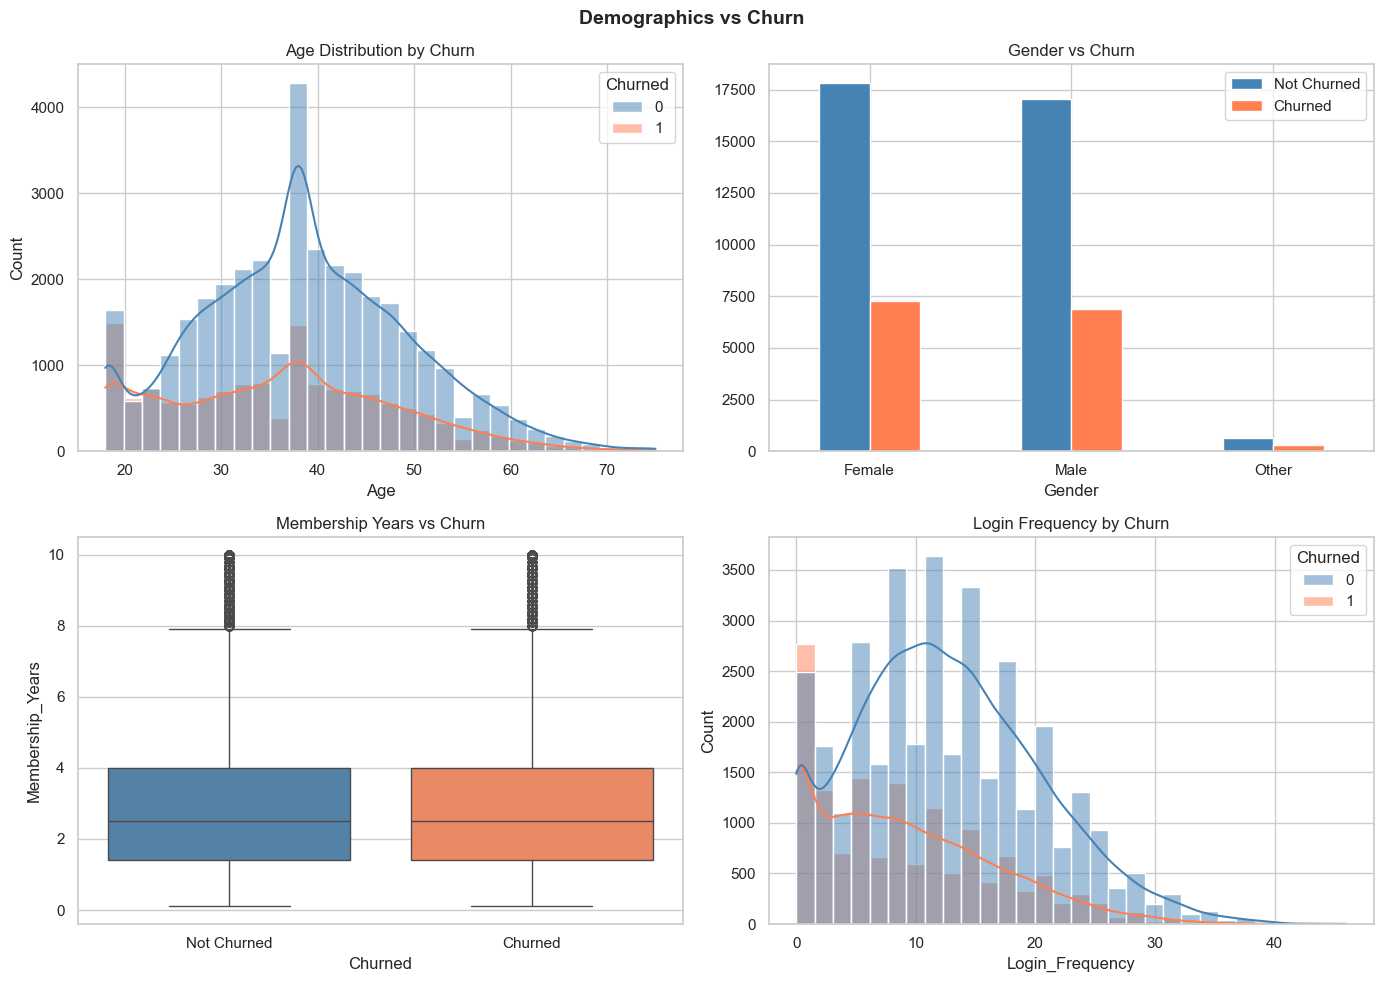

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(data=df, x='Age', hue='Churned', bins=30, kde=True,
             palette=['steelblue', 'coral'], ax=axes[0,0])
axes[0,0].set_title('Age Distribution by Churn')
gender_churn = df.groupby(['Gender', 'Churned']).size().unstack()
gender_churn.plot(kind='bar', ax=axes[0,1], color=['steelblue', 'coral'], edgecolor='white', rot=0)
axes[0,1].set_title('Gender vs Churn')
axes[0,1].legend(['Not Churned', 'Churned'])
sns.boxplot(x='Churned', y='Membership_Years', data=df,
            palette=['steelblue', 'coral'], ax=axes[1,0])
axes[1,0].set_title('Membership Years vs Churn')
axes[1,0].set_xticklabels(['Not Churned', 'Churned'])
sns.histplot(data=df, x='Login_Frequency', hue='Churned', bins=30, kde=True,
             palette=['steelblue', 'coral'], ax=axes[1,1])
axes[1,1].set_title('Login Frequency by Churn')
plt.suptitle('Demographics vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Activity, Purchase & Engagement vs Churn

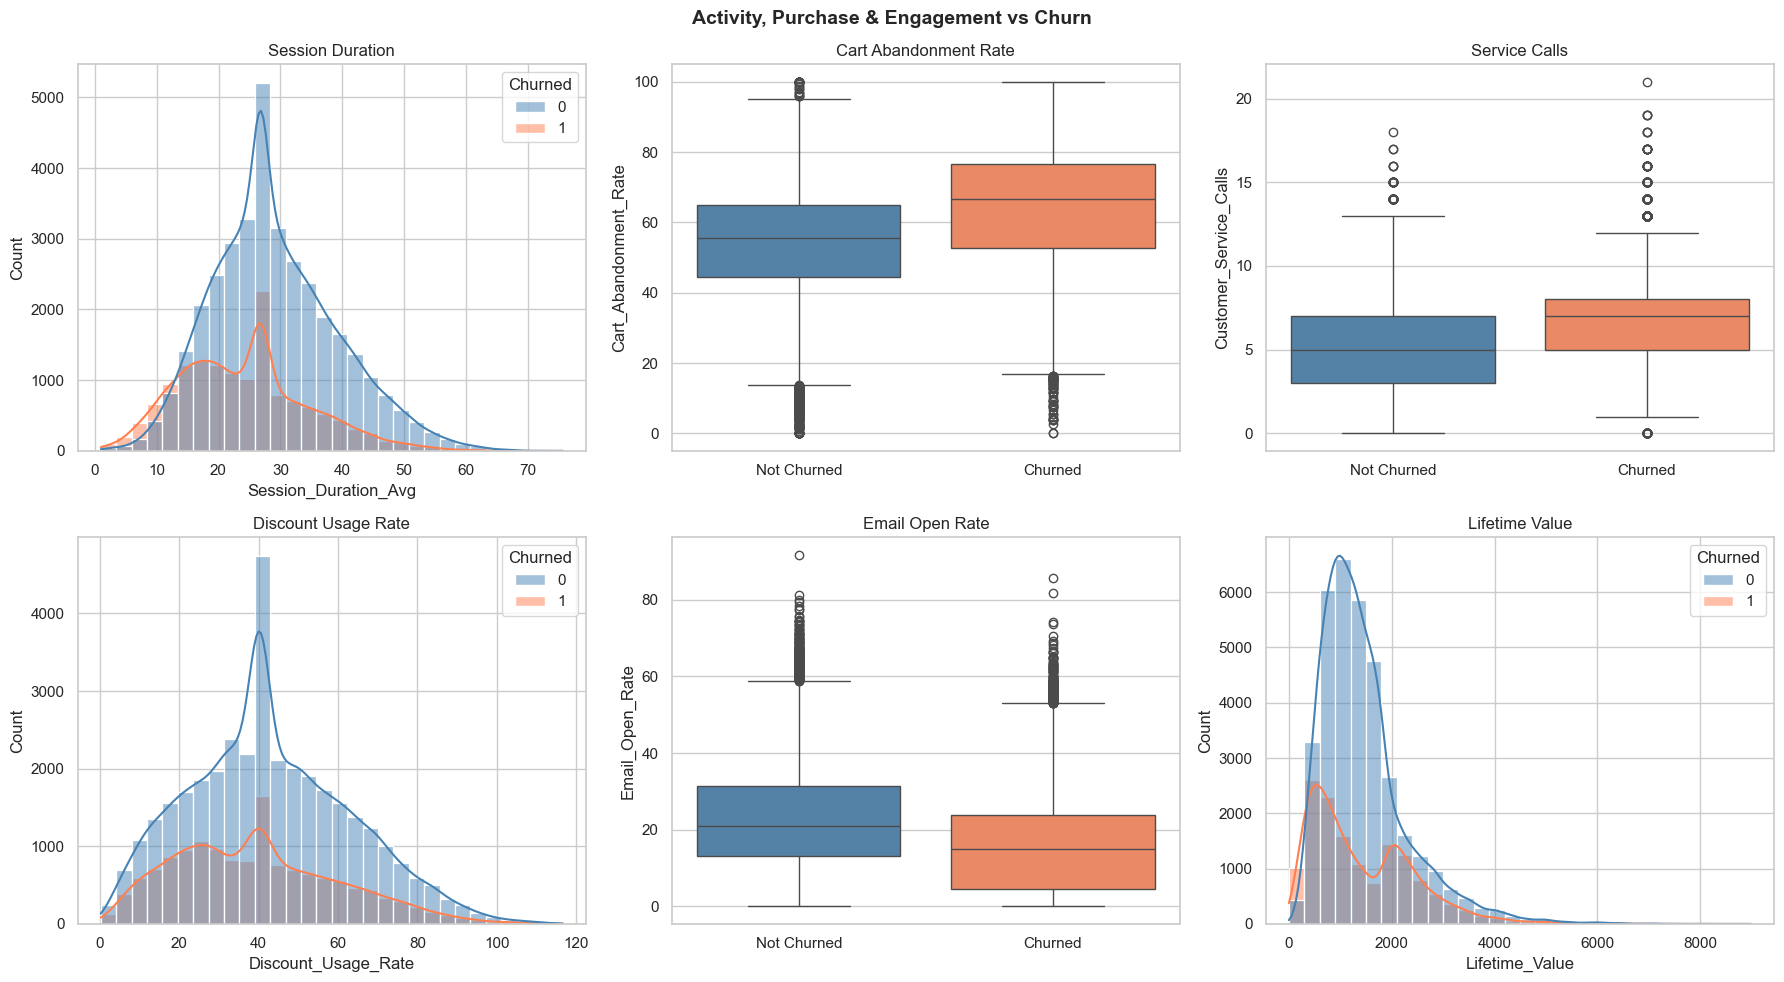

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
features = [
    ('Session_Duration_Avg',   'Session Duration',      'hist'),
    ('Cart_Abandonment_Rate',  'Cart Abandonment Rate', 'box'),
    ('Customer_Service_Calls', 'Service Calls',         'box'),
    ('Discount_Usage_Rate',    'Discount Usage Rate',   'hist'),
    ('Email_Open_Rate',        'Email Open Rate',       'box'),
    ('Lifetime_Value',         'Lifetime Value',        'hist'),
]
for ax, (col, title, kind) in zip(axes.flatten(), features):
    if kind == 'box':
        sns.boxplot(x='Churned', y=col, data=df, palette=['steelblue','coral'], ax=ax)
        ax.set_xticklabels(['Not Churned', 'Churned'])
        ax.set_xlabel('')
    else:
        sns.histplot(data=df, x=col, hue='Churned', bins=30, kde=True,
                     palette=['steelblue','coral'], ax=ax)
    ax.set_title(title)
plt.suptitle('Activity, Purchase & Engagement vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.4 Correlation Heatmap & Feature Correlation with Churn

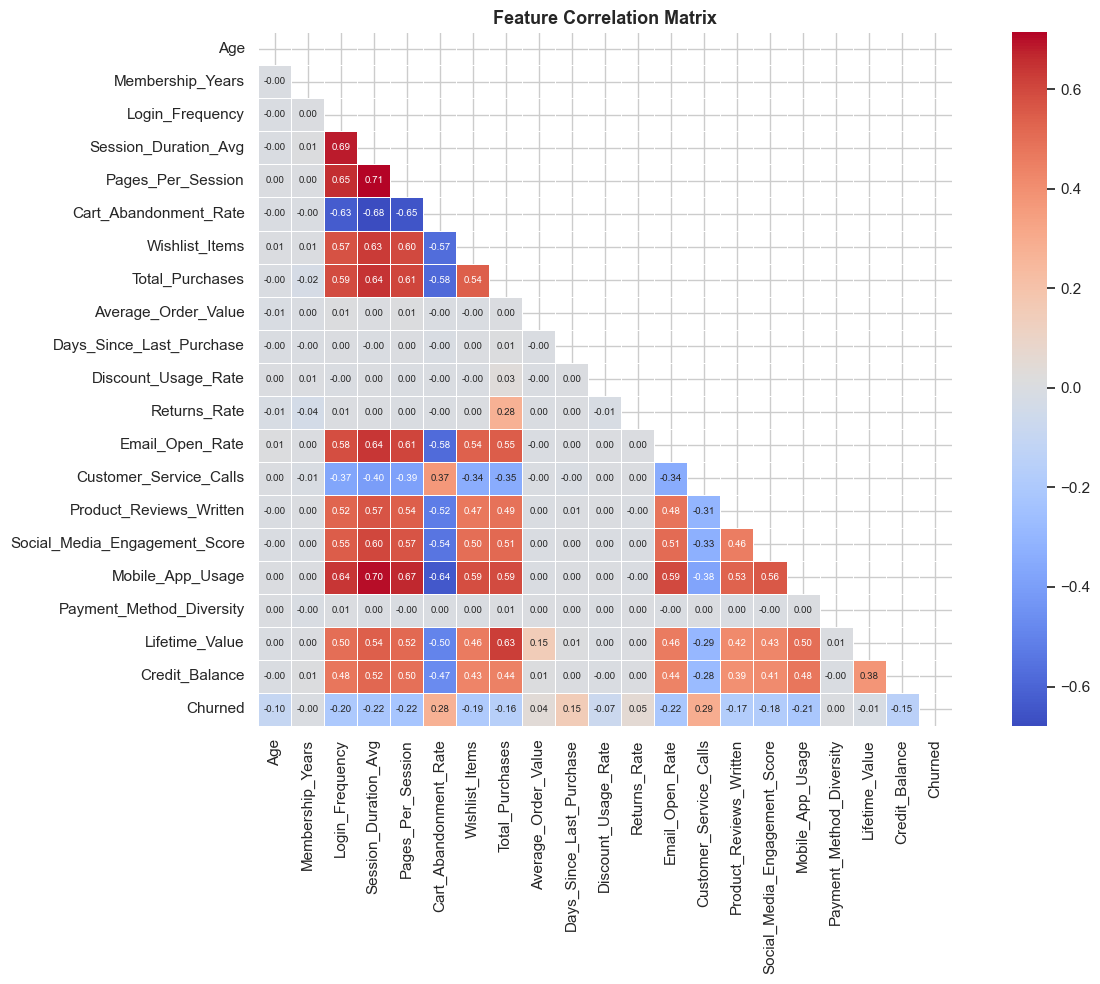

In [16]:
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, square=True, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

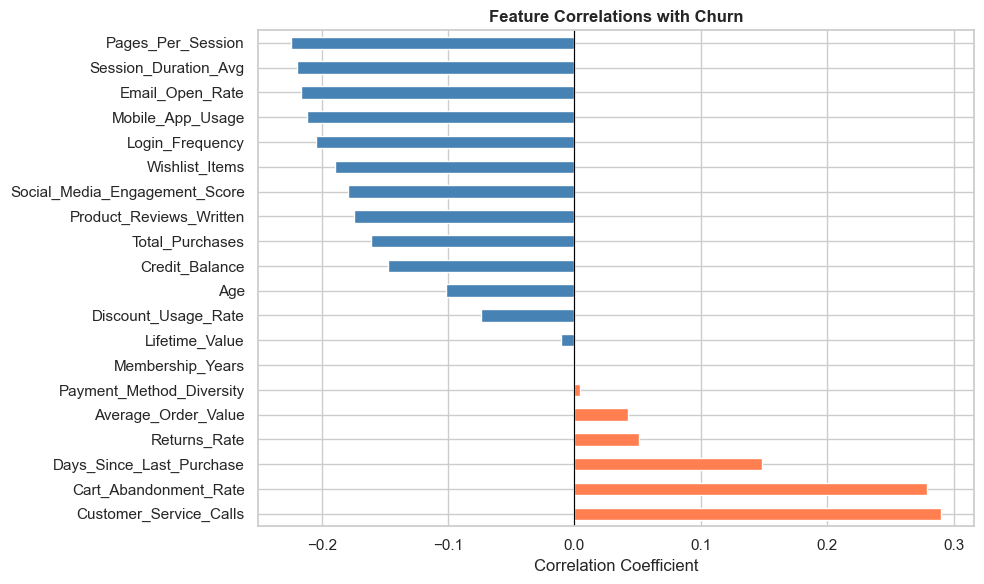

Customer_Service_Calls           0.290407
Cart_Abandonment_Rate            0.278721
Days_Since_Last_Purchase         0.148437
Returns_Rate                     0.051082
Average_Order_Value              0.042268
Payment_Method_Diversity         0.004742
Membership_Years                -0.000418
Lifetime_Value                  -0.010687
Discount_Usage_Rate             -0.074188
Age                             -0.101972
Credit_Balance                  -0.147917
Total_Purchases                 -0.160947
Product_Reviews_Written         -0.174309
Social_Media_Engagement_Score   -0.179568
Wishlist_Items                  -0.189604
Login_Frequency                 -0.204217
Mobile_App_Usage                -0.211298
Email_Open_Rate                 -0.216072
Session_Duration_Avg            -0.219595
Pages_Per_Session               -0.224623
Name: Churned, dtype: float64


In [17]:
churn_corr = df.corr(numeric_only=True)['Churned'].drop('Churned').sort_values(ascending=False)
plt.figure(figsize=(10, 6))
colors = ['coral' if v > 0 else 'steelblue' for v in churn_corr]
churn_corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlations with Churn', fontsize=12, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()
print(churn_corr)

## 6. Encoding & Train/Test Split

In [18]:
# Separate the features (X) from the target variable (y)
# X = all columns except 'Churned'
# y = the 'Churned' column (what we are trying to predict)
X = df.drop('Churned', axis=1)
y = df['Churned']

# Convert categorical text columns into numeric columns using one-hot encoding
# drop_first=True avoids creating redundant columns (e.g., if Male/Female, we only need one)
X = pd.get_dummies(X, drop_first=True)

print("Feature shape:", X.shape)
X.head()

Feature shape: (49950, 22)


,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Gender_Male,Gender_Other
0,43,2.9,14.0,27.4,6.0,50.6,3,9,94.72,34,...,17.9,9,4,16.3,20.8,1,953.33,2278.0,True,False
1,36,1.6,15.0,42.7,10.3,37.7,1,19,82.45,71,...,42.8,7,3,27.6,23.3,3,1067.47,3028.0,True,False
2,45,2.9,10.0,24.8,1.6,70.9,1,9,165.52,11,...,0.0,4,1,27.6,8.8,2,1289.75,2317.0,False,False
3,56,2.6,10.0,38.4,14.8,41.7,9,15,147.33,47,...,41.4,2,5,85.9,31.0,3,2340.92,2674.0,False,False
4,35,3.1,29.0,51.4,8.4,19.1,9,32,141.30,73,...,37.9,1,11,83.0,50.4,4,3041.29,5354.0,True,False


In [19]:
# Split the data into training set (80%) and testing set (20%)
# stratify=y ensures both splits have the same churn ratio as the original data
# random_state=42 makes the split reproducible (same result every run)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Churn rate — Train: {y_train.mean():.3f}  |  Test: {y_test.mean():.3f}")

Train: (39960, 22)  |  Test: (9990, 22)
Churn rate — Train: 0.289  |  Test: 0.289


## 7. Scaling — StandardScaler

Outliers properly managed → StandardScaler is appropriate.

In [20]:
# StandardScaler transforms each feature to have mean=0 and standard deviation=1
# This prevents features with large values (like Lifetime_Value) from dominating the model

scaler = StandardScaler()

# fit_transform on training data: learns the mean/std AND applies the transformation
X_train_scaled = scaler.fit_transform(X_train)

# transform only on test data: applies the SAME transformation learned from training
# (we never fit on test data — that would cause data leakage)
X_test_scaled = scaler.transform(X_test)

## 8. Model Comparison — Default Parameters

All 9 models with default settings on original data. Establishes baseline.

In [ ]:
# ── Helper function: evaluate all models ──
# This function takes training data, test data, and a label string.
# It trains all 9 models, evaluates each one, and returns a results table.

def evaluate_models(X_tr, X_te, y_tr, y_te, label):

    # Define all 9 models we want to compare
    models = {
        "Logistic Regression" : LogisticRegression(max_iter=1000),
        "Decision Tree"       : DecisionTreeClassifier(),
        "Random Forest"       : RandomForestClassifier(),
        "Gradient Boosting"   : GradientBoostingClassifier(),
        "AdaBoost"            : AdaBoostClassifier(),
        "Naive Bayes"         : GaussianNB(),
        "SVM"                 : SVC(probability=True),
        "KNN"                 : KNeighborsClassifier(),
        "XGBoost"             : XGBClassifier(eval_metric='logloss')
    }

    # We'll store each model's results as a row in this list
    rows = []

    # Loop through each model one by one
    for name, model in models.items():

        # Train the model on the training data
        model.fit(X_tr, y_tr)

        # Predict class labels (0 or 1) for the test data
        y_pred_m = model.predict(X_te)

        # Predict probabilities (needed for ROC-AUC score)
        # Not all models support predict_proba, so we check first
        if hasattr(model, 'predict_proba'):
            y_prob_m = model.predict_proba(X_te)[:, 1]  # probability of class 1 (churned)
        else:
            y_prob_m = None

        # Calculate all evaluation metrics and store them in a dictionary
        result_row = {
            "Model"     : name,
            "Accuracy"  : round(accuracy_score(y_te, y_pred_m), 4),
            "Precision" : round(precision_score(y_te, y_pred_m, zero_division=0), 4),
            "Recall"    : round(recall_score(y_te, y_pred_m), 4),
            "F1"        : round(f1_score(y_te, y_pred_m), 4),
            "ROC-AUC"   : round(roc_auc_score(y_te, y_prob_m), 4) if y_prob_m is not None else None,
        }

        rows.append(result_row)

    # Convert the list of result rows into a DataFrame
    df_res = pd.DataFrame(rows)

    # Sort models from best to worst ROC-AUC score
    df_res = df_res.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

    # Add the strategy label to each metric column name (e.g., "Accuracy (Default)")
    metric_columns = df_res.columns[1:]  # all columns except 'Model'
    new_column_names = ["Model"] + [f"{col} ({label})" for col in metric_columns]
    df_res.columns = new_column_names

    return df_res


# Run the evaluation on original data with default model parameters
default_results = evaluate_models(X_train_scaled, X_test_scaled, y_train, y_test, "Default")
default_results

## 9. Model Comparison — SMOTE Oversampling (Default Params)

Synthetically balance minority class → retrain all models with default params.

In [ ]:
# SMOTE = Synthetic Minority Oversampling Technique
# It creates new artificial examples of the minority class (churned customers)
# so that the model doesn't become biased toward predicting 'not churned'

smote = SMOTE(random_state=42)

# Apply SMOTE only to the training data — never touch the test data
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After  SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())

# Scale the SMOTE-resampled training data (fit a NEW scaler on this new training set)
scaler_sm = StandardScaler()
X_train_sm_scaled = scaler_sm.fit_transform(X_train_sm)

# Apply the same scaler to the test data (no refitting)
X_test_sm_scaled = scaler_sm.transform(X_test)

# Evaluate all models on the SMOTE-balanced data
smote_default_results = evaluate_models(
    X_train_sm_scaled, X_test_sm_scaled,
    y_train_sm, y_test,
    "SMOTE-Default"
)
smote_default_results

## 10. Model Comparison — Random Undersampling (Default Params)

Reduce majority class to match minority → retrain all models with default params.

In [ ]:
# Random Undersampling removes rows from the majority class (not churned)
# until it matches the size of the minority class (churned)
# This is the opposite approach to SMOTE

rus = RandomUnderSampler(random_state=42)

# Apply undersampling only to the training data
X_train_us, y_train_us = rus.fit_resample(X_train, y_train)

print("Before Undersampling:", y_train.value_counts().to_dict())
print("After  Undersampling:", pd.Series(y_train_us).value_counts().to_dict())

# Scale the undersampled training data
scaler_us = StandardScaler()
X_train_us_scaled = scaler_us.fit_transform(X_train_us)

# Apply the same scaler to the test data
X_test_us_scaled = scaler_us.transform(X_test)

# Evaluate all models on the undersampled data
under_default_results = evaluate_models(
    X_train_us_scaled, X_test_us_scaled,
    y_train_us, y_test,
    "Under-Default"
)
under_default_results

## 11. Default Summary Table — All 3 Strategies

Compare all models across Default / SMOTE / Undersampling with default parameters.
**Pick top 3 models by ROC-AUC → tune only those in next sections.**

In [ ]:
# Merge all three results tables side by side using the 'Model' column as the key
# This gives us one big table comparing all models across all 3 strategies
default_summary = default_results.merge(smote_default_results, on="Model")
default_summary = default_summary.merge(under_default_results, on="Model")

print("=== Default Params Summary ===")
default_summary

In [ ]:
# Visual comparison
roc_cols = [c for c in default_summary.columns if 'ROC-AUC' in c]
default_summary[['Model'] + roc_cols].set_index('Model').plot(
    kind='barh', figsize=(13, 6), colormap='Set2', edgecolor='white')
plt.title('ROC-AUC — Default vs SMOTE-Default vs Under-Default',
          fontsize=13, fontweight='bold')
plt.xlabel('ROC-AUC')
plt.axvline(0.5, color='red', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

In [ ]:
# Find the best ROC-AUC each model achieved across any of the 3 strategies
roc_cols = [c for c in default_summary.columns if 'ROC-AUC' in c]

# For each row (model), find the maximum ROC-AUC value across the 3 strategy columns
default_summary['Best_Default_ROC'] = default_summary[roc_cols].max(axis=1)

# Select the top 3 models based on that best ROC-AUC
top3_models = default_summary.nlargest(3, 'Best_Default_ROC')['Model'].tolist()

print("Top 3 models selected for hyperparameter tuning:")
for i, m in enumerate(top3_models, 1):
    print(f"  {i}. {m}")

## 12. Hyperparameter Tuning — Top Models on Original Data

GridSearchCV on top 3 models only — original (unsampled) data.
`cv=3` and `n_jobs=-1` for speed.

In [ ]:
# Define the hyperparameter grid for each model
# GridSearchCV will try all combinations and find the best one
all_param_grids = {
    "Logistic Regression" : {"C": [0.1, 1, 10]},
    "Decision Tree"       : {"max_depth": [3, 5, 7], "criterion": ["gini", "entropy"]},
    "Random Forest"       : {"n_estimators": [100, 200], "max_depth": [5, 7]},
    "Gradient Boosting"   : {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3, 5]},
    "AdaBoost"            : {"n_estimators": [100, 200], "learning_rate": [0.1, 1.0]},
    "Naive Bayes"         : {},
    "SVM"                 : {"C": [0.1, 1, 10], "kernel": ["rbf", "linear"]},
    "KNN"                 : {"n_neighbors": [3, 5, 7], "weights": ["uniform", "distance"]},
    "XGBoost"             : {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3, 5]},
}

# Create a fresh instance of each model (used as the base for tuning)
all_model_instances = {
    "Logistic Regression" : LogisticRegression(max_iter=1000),
    "Decision Tree"       : DecisionTreeClassifier(),
    "Random Forest"       : RandomForestClassifier(),
    "Gradient Boosting"   : GradientBoostingClassifier(random_state=42),
    "AdaBoost"            : AdaBoostClassifier(random_state=42),
    "Naive Bayes"         : GaussianNB(),
    "SVM"                 : SVC(probability=True),
    "KNN"                 : KNeighborsClassifier(),
    "XGBoost"             : XGBClassifier(eval_metric='logloss', random_state=42),
}


# ── Helper function: tune only the selected top models using GridSearchCV ──
def tune_top_models(X_tr, X_te, y_tr, y_te, label, top_models):
    """Run GridSearchCV only on top_models list."""

    # Dictionary to store the best trained model for each name
    tuned_store = {}

    # List to collect results for each model
    rows = []

    # Loop through each of the top model names
    for name in top_models:

        # Get the model instance and its parameter grid
        model = all_model_instances[name]
        pg = all_param_grids[name]

        # If the model has hyperparameters to tune, use GridSearchCV
        if pg:
            # GridSearchCV tries all combinations and picks the best by ROC-AUC
            # cv=3 means 3-fold cross validation
            # n_jobs=-1 means use all available CPU cores to speed up
            gs = GridSearchCV(model, pg, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0)
            gs.fit(X_tr, y_tr)
            best = gs.best_estimator_  # the model with the best parameter combination
            print(f"{name:25s} | Best: {gs.best_params_}")
        else:
            # Naive Bayes has no hyperparameters — just train it directly
            best = model
            best.fit(X_tr, y_tr)
            print(f"{name:25s} | No params to tune")

        # Save the best model so we can use it later
        tuned_store[name] = best

        # Make predictions on the test data
        y_pred_t = best.predict(X_te)

        # Get probability predictions for ROC-AUC
        if hasattr(best, 'predict_proba'):
            y_prob_t = best.predict_proba(X_te)[:, 1]
        else:
            y_prob_t = None

        # Store all evaluation metrics in a row
        result_row = {
            "Model"     : name,
            "Accuracy"  : round(accuracy_score(y_te, y_pred_t), 4),
            "Precision" : round(precision_score(y_te, y_pred_t, zero_division=0), 4),
            "Recall"    : round(recall_score(y_te, y_pred_t), 4),
            "F1"        : round(f1_score(y_te, y_pred_t), 4),
            "ROC-AUC"   : round(roc_auc_score(y_te, y_prob_t), 4) if y_prob_t is not None else None,
        }
        rows.append(result_row)

    # Build the results DataFrame, sort by ROC-AUC, and label columns with strategy name
    df_res = pd.DataFrame(rows)
    df_res = df_res.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
    metric_columns = df_res.columns[1:]
    new_column_names = ["Model"] + [f"{col} ({label})" for col in metric_columns]
    df_res.columns = new_column_names

    return df_res, tuned_store


print("=== Tuning Top 3 on Original Data ===")
tuned_orig_results, tuned_orig_store = tune_top_models(
    X_train_scaled, X_test_scaled, y_train, y_test, "Tuned-Original", top3_models
)
tuned_orig_results

## 13. Hyperparameter Tuning — Top Models on SMOTE Data

Same top 3 models, now tuned on SMOTE-resampled data.

In [ ]:
# Same tuning process, but this time using the SMOTE-balanced training data
print("=== Tuning Top 3 on SMOTE Data ===")
tuned_smote_results, tuned_smote_store = tune_top_models(
    X_train_sm_scaled, X_test_sm_scaled, y_train_sm, y_test, "Tuned-SMOTE", top3_models
)
tuned_smote_results

## 14. Hyperparameter Tuning — Top Models on Undersampled Data

Same top 3 models, now tuned on undersampled data.

In [ ]:
# Same tuning process, but this time using the undersampled training data
print("=== Tuning Top 3 on Undersampled Data ===")
tuned_under_results, tuned_under_store = tune_top_models(
    X_train_us_scaled, X_test_us_scaled, y_train_us, y_test, "Tuned-Under", top3_models
)
tuned_under_results

## 15. Grand Summary Table — All 6 Strategies

Mirrors mentor's approach exactly:
- Default · SMOTE-Default · Under-Default · Tuned-Original · Tuned-SMOTE · Tuned-Under

Best model & strategy auto-selected by highest ROC-AUC.

In [ ]:
# Extract the ROC-AUC column name from each tuned result table
# (the column name includes the strategy label, e.g. 'ROC-AUC (Tuned-Original)')
tuned_orig_roc_col  = [c for c in tuned_orig_results.columns  if 'ROC-AUC' in c][0]
tuned_smote_roc_col = [c for c in tuned_smote_results.columns if 'ROC-AUC' in c][0]
tuned_under_roc_col = [c for c in tuned_under_results.columns if 'ROC-AUC' in c][0]

# Start with the default summary (which already has 3 ROC-AUC columns)
# Then merge in the tuned ROC-AUC columns one by one
# Only the top 3 models have tuned results — others will show NaN
grand_summary = default_summary[['Model'] + roc_cols]
grand_summary = grand_summary.merge(tuned_orig_results[['Model', tuned_orig_roc_col]],  on='Model', how='left')
grand_summary = grand_summary.merge(tuned_smote_results[['Model', tuned_smote_roc_col]], on='Model', how='left')
grand_summary = grand_summary.merge(tuned_under_results[['Model', tuned_under_roc_col]], on='Model', how='left')

print("=== Grand Summary — ROC-AUC across all 6 strategies ===")
grand_summary

In [ ]:
# Visual
all_roc_cols = [c for c in grand_summary.columns if 'ROC-AUC' in c]
grand_summary[['Model'] + all_roc_cols].set_index('Model').plot(
    kind='barh', figsize=(16, 8), colormap='tab10', edgecolor='white')
plt.title('ROC-AUC — All 6 Strategies', fontsize=13, fontweight='bold')
plt.xlabel('ROC-AUC')
plt.axvline(0.5, color='red', linestyle='--', linewidth=0.8, label='Random baseline')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Automatically find which model and strategy gives the best ROC-AUC score

all_roc_cols = [c for c in grand_summary.columns if 'ROC-AUC' in c]

# Start with placeholder values
best_val = 0
best_model_name = ""
best_strategy = ""

# Loop through every row (model) and every ROC-AUC column (strategy)
for _, row in grand_summary.iterrows():
    for col in all_roc_cols:
        val = row[col]
        # Update if this value is valid and better than what we've seen so far
        if pd.notna(val) and val > best_val:
            best_val = val
            best_model_name = row["Model"]
            # Extract the strategy name from the column name (it's inside the parentheses)
            best_strategy = col.split("(")[-1].replace(")", "").strip()

print(f"\u2705 Best Model    : {best_model_name}")
print(f"\u2705 Best Strategy : {best_strategy}")
print(f"\u2705 Best ROC-AUC  : {best_val}")

## 16. Final Model Evaluation & Threshold Tuning

In [ ]:
# Map each strategy name to: (training features, training labels, scaler, tuned model store)
# This lets us easily retrieve the right data and model for whichever strategy won
strategy_map = {
    "Default"        : (X_train_scaled,    y_train,    scaler,    None),
    "SMOTE-Default"  : (X_train_sm_scaled, y_train_sm, scaler_sm, None),
    "Under-Default"  : (X_train_us_scaled, y_train_us, scaler_us, None),
    "Tuned-Original" : (X_train_scaled,    y_train,    scaler,    tuned_orig_store),
    "Tuned-SMOTE"    : (X_train_sm_scaled, y_train_sm, scaler_sm, tuned_smote_store),
    "Tuned-Under"    : (X_train_us_scaled, y_train_us, scaler_us, tuned_under_store),
}

# Retrieve the correct training data, scaler, and model store for the best strategy
X_train_best, y_train_best, scaler_best, store = strategy_map[best_strategy]

# If the best strategy was a tuned one, retrieve the already-trained best model
# Otherwise, refit the default model on the appropriate training data
if store and best_model_name in store:
    best_model = store[best_model_name]
else:
    # Default strategy — refit
    best_model = all_model_instances[best_model_name]
    best_model.fit(X_train_best, y_train_best)

# Scale the test data using the scaler associated with the best strategy
X_test_final = scaler_best.transform(X_test)

# Get predicted probabilities for the test set
y_prob = best_model.predict_proba(X_test_final)[:, 1]

# Default prediction: classify as churned if probability >= 0.5
y_pred = (y_prob >= 0.5).astype(int)

print(f"Model   : {best_model_name}")
print(f"Strategy: {best_strategy}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}")

In [ ]:
# Plot the ROC Curve — shows the trade-off between true positive rate and false positive rate
# A curve closer to the top-left corner means a better model

auc_score = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], '--', color='gray')  # diagonal = random model baseline
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve — {best_model_name} ({best_strategy})', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Threshold Tuning
# By default, predictions use a threshold of 0.5 (predict churn if prob >= 0.5)
# We can try different thresholds to find the one that gives the best F1 score

best_t = 0.5          # starting threshold
best_f1_score = 0     # best F1 found so far

# Try every threshold from 0.25 to 0.64 in steps of 0.01
for t in np.arange(0.25, 0.65, 0.01):
    # Apply this threshold to the predicted probabilities
    y_t = (y_prob >= t).astype(int)

    # Calculate F1 score for this threshold
    f = f1_score(y_test, y_t)

    # Keep track of the threshold that gives the highest F1
    if f > best_f1_score:
        best_f1_score = f
        best_t = t

print(f"Best threshold : {best_t:.2f}  →  Best F1: {best_f1_score:.4f}")

# Apply the best threshold to get the final tuned predictions
y_pred_tuned = (y_prob >= best_t).astype(int)

In [ ]:
# Plot confusion matrices side by side:
# Left: using the default 0.5 threshold
# Right: using the tuned threshold
# A confusion matrix shows how many predictions were correct/incorrect for each class

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (preds, label) in zip(axes, [
    (y_pred,       "Default Threshold (0.50)"),
    (y_pred_tuned, f"Tuned Threshold ({best_t:.2f})")
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Churned','Churned'],
                yticklabels=['Not Churned','Churned'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {label}', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Print a full classification report for both thresholds
# This shows precision, recall, and F1 for each class separately

print("=== Default Threshold (0.50) ===")
print(classification_report(y_test, y_pred, target_names=['Not Churned','Churned']))

print(f"\n=== Tuned Threshold ({best_t:.2f}) ===")
print(classification_report(y_test, y_pred_tuned, target_names=['Not Churned','Churned']))

## 17. Overfitting / Underfitting Check — Learning Curve
- Train >> Validation → **Overfitting**
- Both low → **Underfitting**
- Both close and high → **Good fit ✅**

In [ ]:
# Compute learning curve data
# This trains the model on increasing amounts of training data
# and records both the training score and validation score at each size
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train_best, y_train_best,
    cv=5,                              # 5-fold cross validation
    scoring='roc_auc',                 # evaluate using ROC-AUC
    n_jobs=-1,                         # use all CPU cores for speed
    train_sizes=np.linspace(0.1, 1.0, 10)  # 10 evenly spaced training sizes from 10% to 100%
)

# Calculate the mean and standard deviation across the 5 folds
train_mean = np.mean(train_scores, axis=1)
test_mean  = np.mean(test_scores,  axis=1)
train_std  = np.std(train_scores,  axis=1)
test_std   = np.std(test_scores,   axis=1)

# Plot the learning curve
plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training ROC-AUC')
plt.plot(train_sizes, test_mean,  'o-', color='coral',     label='Validation ROC-AUC')

# Shaded area shows the variability (standard deviation) across folds
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='steelblue')
plt.fill_between(train_sizes, test_mean  - test_std,  test_mean  + test_std,  alpha=0.1, color='coral')

plt.xlabel('Training Size')
plt.ylabel('ROC-AUC Score')
plt.title('Learning Curve — Overfitting / Underfitting Check', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Check the final gap between training and validation scores
gap = train_mean[-1] - test_mean[-1]

print(f"Train ROC-AUC : {train_mean[-1]:.4f}")
print(f"Val   ROC-AUC : {test_mean[-1]:.4f}")
print(f"Gap           : {gap:.4f}")

# Interpret the result
if gap > 0.1:
    print("\u26a0\ufe0f  Possible overfitting")
elif test_mean[-1] < 0.75:
    print("\u26a0\ufe0f  Possible underfitting")
else:
    print("\u2705 Good fit")

## 18. Feature Importances

In [ ]:
# Check if the best model supports feature importances
# (Tree-based models like Random Forest, XGBoost, Gradient Boosting support this)
if hasattr(best_model, 'feature_importances_'):

    # Create a Series mapping each feature name to its importance score
    importance = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    )

    # Sort from most to least important
    importance = importance.sort_values(ascending=False)

    # Plot the top 10 most important features
    importance.head(10).sort_values().plot(
        kind='barh', figsize=(10, 6), color='steelblue', edgecolor='white'
    )
    plt.title(f'Top 10 Features — {best_model_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    print(importance.head(10))

else:
    print(f"{best_model_name} does not support feature_importances_ directly.")

## 19. Save Artifacts

In [ ]:
import pickle

# Save the trained model so we can load and use it later without retraining
pickle.dump(best_model, open("churn_model.pkl", "wb"))

# Save the scaler so we can apply the same transformation to new data
pickle.dump(scaler_best, open("scaler.pkl", "wb"))

# Save the list of feature column names so we know the expected input format
pickle.dump(X.columns.tolist(), open("feature_columns.pkl", "wb"))

# Save the best threshold so we can use the same decision boundary on new predictions
pickle.dump(best_t, open("best_threshold.pkl", "wb"))

print("\u2705 Saved: churn_model.pkl, scaler.pkl, feature_columns.pkl, best_threshold.pkl")
print(f"   Best model    : {best_model_name}")
print(f"   Best strategy : {best_strategy}")
print(f"   Best ROC-AUC  : {best_val}")
print(f"   Best threshold: {best_t:.2f}")